In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# Load the dataset
df = pd.read_csv(r"/content/salary_experience_dataset.csv")

# Display the first few rows to understand the structure
print(df.head(10))
df.shape

   Experience  Salary
0        0.00   32270
1        0.20   26660
2        0.40   31990
3        0.61   32631
4        0.81   33974
5        1.01   35305
6        1.21   30306
7        1.41   35066
8        1.62   37058
9        1.82   40602


(100, 2)

In [8]:
# Check for missing values
print(df.isnull().sum())


Experience    0
Salary        0
dtype: int64


In [9]:
# Features (independent variable) and target (dependent variable)
# Independent variable (Temperature)
X = df[['Experience']]
# Dependent variable (Energy Consumption)
y = df['Salary']


In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=24)
print(X_test)

    Experience
26        5.25
31        6.26
37        7.47
86       17.37
76       15.35
14        2.83
88       17.78
48        9.70
71       14.34
67       13.54
13        2.63
84       16.97
58       11.72
40        8.08
75       15.15
94       18.99
20        4.04
57       11.52
61       12.32
80       16.16


In [11]:
print(y_test)

26     48747
31     53045
37     58436
86     94544
76     87278
14     41631
88     98688
48     69286
71     88799
67     86789
13     37953
84     98156
58     72901
40     62713
75     94129
94    106578
20     47556
57     74153
61     83972
80     95971
Name: Salary, dtype: int64


In [12]:
# Create a Linear Regression model
model = LinearRegression()
# Train the model
model.fit(X_train, y_train)


LinearRegression()

In [13]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred

array([ 51109.04874153,  55199.33845215,  60099.58652131, 100192.52526895,
        92011.94584772,  41308.55260322, 101852.93990396,  69130.62221901,
        87921.6561371 ,  84681.82270294,  40498.59424468,  98572.60855188,
        77311.20164025,  62569.95951485,  91201.98748918, 106753.18797311,
        46208.80067237,  76501.24328171,  79741.07671586,  95292.2771998 ])

In [14]:
y_test

,Salary
26,48747
31,53045
37,58436
86,94544
76,87278
14,41631
88,98688
48,69286
71,88799
67,86789


In [15]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
# Calculate R-Squared value
r2 = r2_score(y_test, y_pred)
print(f"R-Squared: {r2}")

Mean Squared Error: 7153577.552031892
R-Squared: 0.9835855728935601


In [16]:
model.predict([[10.21]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71196.01603328])

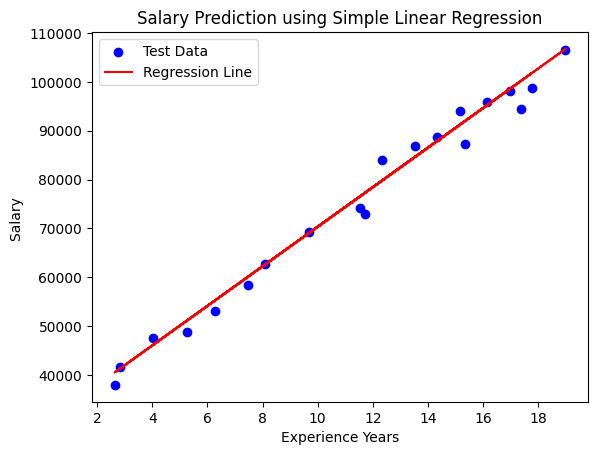

In [17]:
# Plot the test data and regression line
plt.scatter(X_test, y_test, color='blue', label='Test Data')  # Actual data
plt.plot(X_test, y_pred, color='red', label='Regression Line')  # Predicted data
plt.xlabel('Experience Years')
plt.ylabel('Salary ')
plt.legend()
plt.title('Salary Prediction using Simple Linear Regression')
plt.show()

In [18]:
import joblib
import pickle
# Save the model to a file
with open("appliance_salary_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [19]:
import pickle
with open("appliance_salary_model.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [20]:
!pip install gradio

In [21]:
import gradio as gr
import pickle
import numpy as np

# Load trained model
with open("appliance_salary_model.pkl", "rb") as file:
    model = pickle.load(file)

# Prediction function
def predict_salary(experience):
    experience = np.array([[experience]])  # reshape for model
    prediction = model.predict(experience)
    return round(float(prediction[0]), 2)

# Gradio Interface
interface = gr.Interface(
    fn=predict_salary,
    inputs=gr.Number(label="Experience Years"),
    outputs=gr.Number(label="Predicted Salary Consumption"),
    title="Appliance Salary Consumption Prediction",
    description="Predicts salary consumption based on experiance yrar using a trained ML model."
)

# Launch app
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eb69d5bbe00525215d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
